In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import json
import sqlite3

In [4]:
file = "results/tag_results_len9.pkl"

def stream_results(filename):
    with open(filename, 'rb') as f:
        while True:
            try:
                # Reads the next object from the stream
                yield pickle.load(f)
            except EOFError:
                # We reached the end of the file
                break

In [5]:
max_runtime = 100_001
num_runtimes = np.zeros(max_runtime, dtype=int)

# go through all rows in the table
counter = 0
for result in stream_results(file):
    # 'result' is the dictionary for a single simulation
    counter += 1
    steps = result["steps"]
    num_runtimes[steps] += 1

    if counter % 1_000_000 == 0:
        print(f"Processed {counter} results, most common runtime: {np.argmax(num_runtimes[:1000])} with {max(num_runtimes[:1000])} programs")

Processed 1000000 results, most common runtime: 2 with 317253 programs


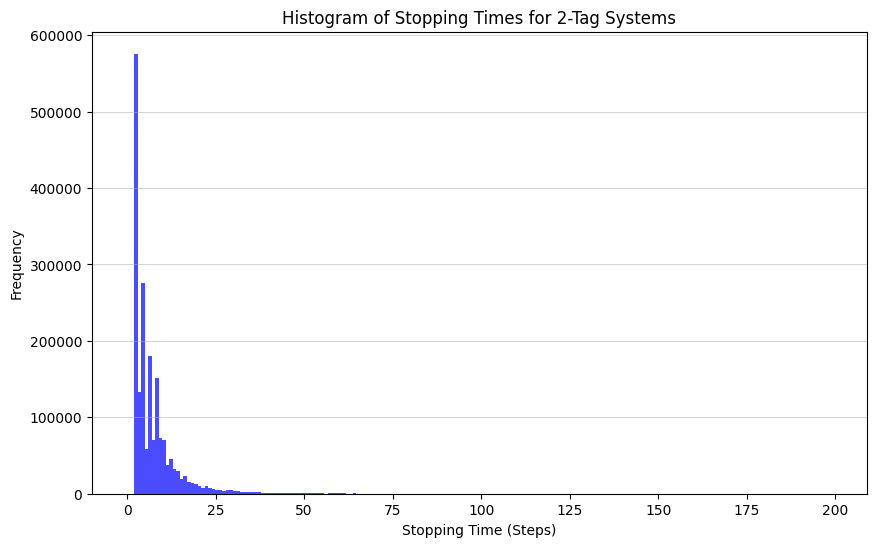

In [6]:
# coarse-grained histogram
num_bins = 200
max_plotted_runtime = 200
halting_num_runtimes = num_runtimes[:max_plotted_runtime]
hist, bin_edges = np.histogram(np.arange(max_plotted_runtime), bins=num_bins, weights=halting_num_runtimes)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0], alpha=0.7, color='blue')
plt.title('Histogram of Stopping Times for 2-Tag Systems')
plt.xlabel('Stopping Time (Steps)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
print(f"Percentage of programs that halt: {np.sum(num_runtimes[:-1]) * 100 / np.sum(num_runtimes)}%")

Percentage of programs that halt: 100.0%


In [14]:
# list runtimes from most common to least common
sorted_indices = np.argsort(num_runtimes)[::-1]  # Sort in descending order
sorted_runtimes = num_runtimes[sorted_indices]

In [19]:
# print 100 most common runtimes
print("Most common runtimes (steps):")
for i in range(100):
    runtime = sorted_indices[i]
    frequency = sorted_runtimes[i]
    print(f"Runtime: {runtime}, Frequency: {frequency}")

Most common runtimes (steps):
Runtime: 2, Frequency: 22719123
Runtime: 4, Frequency: 12223656
Runtime: 100000, Frequency: 11345974
Runtime: 6, Frequency: 8564361
Runtime: 8, Frequency: 7309681
Runtime: 10, Frequency: 6424824
Runtime: 3, Frequency: 5978772
Runtime: 12, Frequency: 4174769
Runtime: 9, Frequency: 3967510
Runtime: 5, Frequency: 3857544
Runtime: 11, Frequency: 3180166
Runtime: 14, Frequency: 3129938
Runtime: 13, Frequency: 2606978
Runtime: 7, Frequency: 2458468
Runtime: 16, Frequency: 1939204
Runtime: 15, Frequency: 1718486
Runtime: 17, Frequency: 1660244
Runtime: 18, Frequency: 1459048
Runtime: 20, Frequency: 1366612
Runtime: 19, Frequency: 1259258
Runtime: 22, Frequency: 1039702
Runtime: 21, Frequency: 968748
Runtime: 24, Frequency: 870048
Runtime: 23, Frequency: 760850
Runtime: 26, Frequency: 695988
Runtime: 25, Frequency: 589304
Runtime: 30, Frequency: 515524
Runtime: 27, Frequency: 510692
Runtime: 28, Frequency: 507252
Runtime: 29, Frequency: 467204
Runtime: 32, Frequen

In [22]:
# print all runtimes that occur exactly once or twice
print("Runtimes that occur exactly once or twice:")
num_runtimes_at_most_twice = 0
for i in range(max_runtime):
    if num_runtimes[i] <= 2 and num_runtimes[i] > 0:
        print(f"Runtime: {i}, Frequency: {num_runtimes[i]}")
        num_runtimes_at_most_twice += 1

print(f"Total number of runtimes that occur at most twice: {num_runtimes_at_most_twice}")

Runtimes that occur exactly once or twice:
Runtime: 544, Frequency: 2
Runtime: 561, Frequency: 2
Runtime: 577, Frequency: 2
Runtime: 616, Frequency: 2
Runtime: 622, Frequency: 2
Runtime: 625, Frequency: 2
Runtime: 631, Frequency: 2
Runtime: 633, Frequency: 2
Runtime: 635, Frequency: 2
Runtime: 636, Frequency: 2
Runtime: 645, Frequency: 2
Runtime: 659, Frequency: 2
Runtime: 661, Frequency: 2
Runtime: 664, Frequency: 2
Runtime: 673, Frequency: 2
Runtime: 675, Frequency: 2
Runtime: 676, Frequency: 2
Runtime: 687, Frequency: 2
Runtime: 691, Frequency: 2
Runtime: 694, Frequency: 2
Runtime: 695, Frequency: 2
Runtime: 716, Frequency: 2
Runtime: 717, Frequency: 2
Runtime: 719, Frequency: 2
Runtime: 727, Frequency: 2
Runtime: 740, Frequency: 2
Runtime: 745, Frequency: 2
Runtime: 746, Frequency: 2
Runtime: 750, Frequency: 2
Runtime: 752, Frequency: 2
Runtime: 753, Frequency: 2
Runtime: 757, Frequency: 2
Runtime: 759, Frequency: 2
Runtime: 760, Frequency: 2
Runtime: 761, Frequency: 2
Runtime: 763

In [31]:
# write runtimes ordered by frequency to a csv file
import csv
with open('tag_runtimes_frequency.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Runtime (Steps)', 'Frequency'])
    for i in range(len(sorted_indices)):
        runtime = sorted_indices[i]
        frequency = sorted_runtimes[i]
        if frequency == 0:
            break
        writer.writerow([runtime, frequency])